# 数据预处理

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import OneHotEncoder

## 数据预处理：
1. 时间列转datetime
2. 按时间排序并设为索引
3. 统一到1h频率
4. 数据列转float64
5. 作差分得到每小时负荷

In [2]:
def build_hr_load_series(
    raw_df: pd.DataFrame,
    ts_col: str,
    cumulative_col: str,
    hr_load_col: str = "hourly_kwh",
):
    df = raw_df.copy()
    df[ts_col] = pd.to_datetime(df[ts_col])
    df = df.sort_values(ts_col).set_index(ts_col)
    df = df.asfreq("1h")
    df[cumulative_col] = pd.to_numeric(df[cumulative_col], errors="coerce").astype(np.float64)

    # 累计电能 -> 每小时负荷
    df[hr_load_col] = df[cumulative_col].diff(1)
    df[hr_load_col] = df[hr_load_col].mask(df[hr_load_col].le(0), np.nan) # 处理非正值
    return df


## 缺失值填充
采用前向均值法：对每个t，取 t-24, t-48, ... t-24*days 的值求均值

1. 正常：缺失点用同序列前7天同小时的均值补全
2. 回退：若可用样本点不足（<2），回退到前14天同小时
3. 兜底：若可用样本点仍不足则用线性插值+前向填充兜底

In [3]:
def fill_missing(s: pd.Series):
    s_filled = s.copy()
    
    # 多级回退：7天 -> 14天
    for lookback_days in [7, 14]:
        shifted_list = [s_filled.shift(24 * d) for d in range(1, lookback_days + 1)]
        hist_df = pd.concat(shifted_list, axis=1)
        valid_cnt = hist_df.notna().sum(axis=1)
        hist_mean = hist_df.mean(axis=1, skipna=True)
        
        # 仅当有足够样本(>=2)且当前值缺失时填充
        fill_mask = s_filled.isna() & (valid_cnt >= 2)
        s_filled.loc[fill_mask] = hist_mean.loc[fill_mask]
    
    # 兜底：时间序列插值 + 前向填充
    s_filled = s_filled.interpolate(method="time", limit_direction="forward").ffill()
    return s_filled

## 异常值检测
使用MAD（Median Absolute Deviation，中位数绝对偏差）方法：

$$ MAD = median\left (\left |X_i - median(X)\right |\right ) $$

当 $ \left |X_i - median\right | > threshold\times MAD $ 时判定为异常值，使用滑动窗口计算局部中位数和局部MAD。

异常值与缺失值统一按前向均值法填充
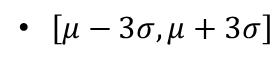
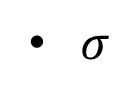
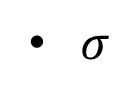

In [4]:
def detect_outliers(
    s: pd.Series,
    window: int = 168,
    threshold: float = 3.0,
) -> pd.Series:
    s_num = s.copy()

    rolling_median = s_num.rolling(window=window, center=True, min_periods=window).median()
    rolling_mad = s_num.rolling(window=window, center=True, min_periods=window).apply(
        lambda x: np.median(np.abs(x - np.median(x))), raw=True
    )

    abs_dev = (s_num - rolling_median).abs()
    ratio = abs_dev / rolling_mad.replace(0, np.nan)

    outlier_mask = ratio > threshold

    # 当窗口内 MAD=0 且当前点偏离局部中位数时，补判为异常
    zero_mad_fallback = (rolling_mad == 0) & (abs_dev > 0)
    outlier_mask = outlier_mask | zero_mad_fallback

    return outlier_mask.fillna(False)



完整预处理流程：预处理 -> 差分 -> 异常值检测 -> 异常值剔除 -> 缺失值填充

In [5]:
base_dir = Path('data')
input_load_path = base_dir / '负荷.CSV'
output_load_path = base_dir / '负荷_预处理后.csv'

raw_load_df = pd.read_csv(input_load_path, encoding="utf-8")

# 预处理（含差分）
clean_load_df = build_hr_load_series(
    raw_load_df,
    ts_col="timestamp",
    cumulative_col="load_kwh",
    hr_load_col="hourly_kwh",
)

# 基于差分的小时负荷做异常值检测
clean_load_df["is_outlier_mad"] = detect_outliers(clean_load_df["hourly_kwh"])

# 异常值剔除后进行缺失值填充
s_no_outlier = clean_load_df["hourly_kwh"].mask(clean_load_df["is_outlier_mad"], np.nan)
clean_load_df["hourly_kwh_clean"] = fill_missing(s_no_outlier).round(2)

clean_load_df.reset_index().to_csv(
    output_load_path,
    index=False,
    header=True,
    encoding="utf-8-sig",
)


## 天气数据清洗与编码

1. 时间列统一为timestamp
2. 删除含缺失值的样本
3. 对降水量进行特殊处理：生成"是否降水"布尔值和"降水量对数变换"特征
4. 对分类数据（如天气状况、风向）做独热编码

In [6]:
input_weather_path = base_dir / '天气.CSV'
output_weather_path = base_dir / '天气_预处理后.csv'

weather_df = pd.read_csv(input_weather_path, encoding='gbk')

# 时间列重命名并转 datetime
if '时间' in weather_df.columns:
    weather_df = weather_df.rename(columns={'时间': 'timestamp'})
weather_df['timestamp'] = pd.to_datetime(weather_df['timestamp'], errors='coerce')

# 缺失值直接剔除
weather_df = weather_df.dropna(axis=0, how='any').copy()

# 降水量特征->是否降水布尔值、降水量对数变换值
def process_precipitation(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    precip_col = '降水量(mm)'
    
    if precip_col in df.columns:
        df['是否降水'] = df[precip_col] > 0
        df['降水量对数变换'] = np.log1p(df[precip_col])
        df = df.drop(columns=[precip_col])
    else:
        df['是否降水'] = False
        df['降水量对数变换'] = 0.0
    return df


# 处理降水量特征
weather_df = process_precipitation(weather_df)

# 分类数据（除 timestamp）使用独热编码
cat_cols = weather_df.select_dtypes(exclude=['number']).columns.tolist()
cat_cols = [c for c in cat_cols if c not in ['timestamp', '是否降水']]

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_arr = ohe.fit_transform(weather_df[cat_cols])
encoded_cols = ohe.get_feature_names_out(cat_cols)
encoded_df = pd.DataFrame(encoded_arr, columns=encoded_cols, index=weather_df.index)
encoded_df = encoded_df.astype('bool')
weather_df = pd.concat([weather_df.drop(columns=cat_cols), encoded_df], axis=1)

# 排序并输出
weather_df = weather_df.sort_values('timestamp').reset_index(drop=True)
weather_df.to_csv(output_weather_path, index=False, encoding='utf-8-sig')

## 时间特征工程

1. 读取日历数据（day_of_week、is_holiday）
2. 添加小时特征
3. 对周期性特征进行 sin/cos 编码

In [7]:
def encode_cyclical_feature(value: pd.Series, max_val: int) -> tuple[pd.Series, pd.Series]:
    sin_val = np.sin(2 * np.pi * value / max_val)
    cos_val = np.cos(2 * np.pi * value / max_val)
    return sin_val, cos_val

# 读取日历特征
calendar_path = base_dir / '2024日历.csv'
calendar_df = pd.read_csv(calendar_path, encoding='utf-8-sig')
calendar_df['date'] = pd.to_datetime(calendar_df['date'].astype(str), format='%Y%m%d')

# 创建时间特征
time_features_df = clean_load_df.reset_index()[['timestamp']].copy()
time_features_df['date'] = time_features_df['timestamp'].dt.normalize()
time_features_df['hour'] = time_features_df['timestamp'].dt.hour
time_features_df = pd.merge(time_features_df, calendar_df, on='date', how='left')

# 周期性编码
time_features_df['hour_sin'], time_features_df['hour_cos'] = encode_cyclical_feature(
    time_features_df['hour'], 24
)
time_features_df['day_of_week_sin'], time_features_df['day_of_week_cos'] = encode_cyclical_feature(
    time_features_df['day_of_week'] - 1, 7  # 转为 0-6
)
time_features_df['month_sin'], time_features_df['month_cos'] = encode_cyclical_feature(
    time_features_df['month'] - 1, 12  # 转为 0-11
)
# 转换为布尔值
time_features_df['is_holiday'] = time_features_df['is_holiday'].astype('bool')

# 移除临时列和原始特征
time_features_df = time_features_df.drop(columns=['date', 'hour', 'day_of_week', 'month'])

## 合并负荷、天气与时间特征

将预处理后的负荷数据、天气数据和时间特征按时间戳合并

In [8]:
# 合并负荷、天气与时间特征
load_cols = ['timestamp', 'hourly_kwh_clean']
load_clean_df = clean_load_df.reset_index()[load_cols]

merged_df = pd.merge(load_clean_df, weather_df, on='timestamp', how='inner')
merged_df = pd.merge(merged_df, time_features_df, on='timestamp', how='inner')

# 排序并导出
merged_df = merged_df.sort_values('timestamp').reset_index(drop=True)
output_path = base_dir / '负荷_天气_时间特征.csv'
# 使用 float_format='%.10f' 强制使用小数点形式，避免科学计数法
merged_df.to_csv(output_path, index=False, encoding='utf-8-sig', float_format='%.10f')